# Modelling the Health Condition of Machines Using Sub-Gaussian Distributions

Presentation-oriented notebook with selected figures for the seminar slides. It keeps the same methodology as the report notebook, but focuses on compact plots and short captions.


In [ ]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import simulation1d
import estimation1d
import simulation2d
import estimation2d

importlib.reload(simulation1d)
importlib.reload(estimation1d)
importlib.reload(simulation2d)
importlib.reload(estimation2d)

from simulation1d import simulate_1d_model
from estimation1d import estimate_1d_model, summarize_1d_estimation, estimate_1d_model_fixed_ar_order
from simulation2d import simulate_2d_model
from estimation2d import estimate_2d_model_fixed_var1, summarize_2d_estimation

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

from estimation2d import estimate_alpha_2d_from_residuals


## 1D Model: Simulation and Estimation

The 1D signal is simulated as $S(t)=T(t)+SC(t)R2(t)$, where $R2(t)$ is AR(1) and the innovations are $S\alpha S$. The selected trajectory below uses $\alpha=1.9$.


In [2]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

base_params = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    phi=(0.5,),
    gamma=1.0,
    sigma1=1.0,
    sigma2=2.5,
    sigma3=5.0,
    sigma4=25.0,
    c1=10.0,
)

In [ ]:
simulation = simulate_1d_model(
    **base_params,
    alpha=1.9,
    random_state=42,
)


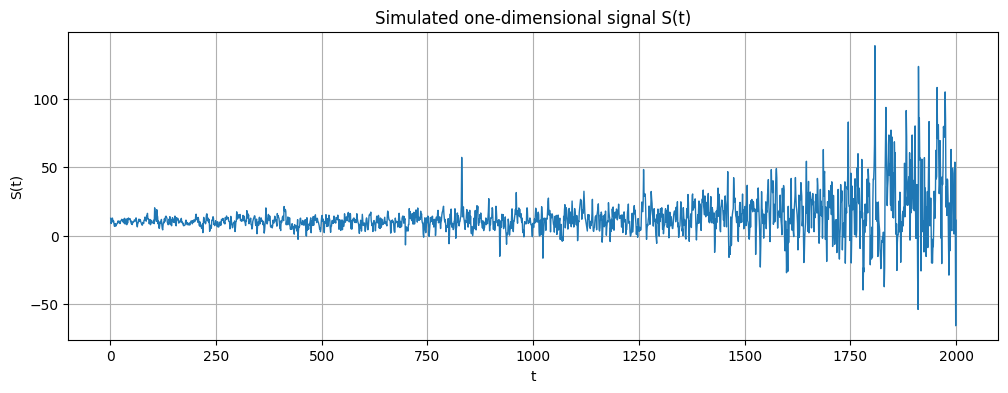

In [4]:
t = simulation["t"]

plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], linewidth=1)
plt.title("Simulated one-dimensional signal S(t)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

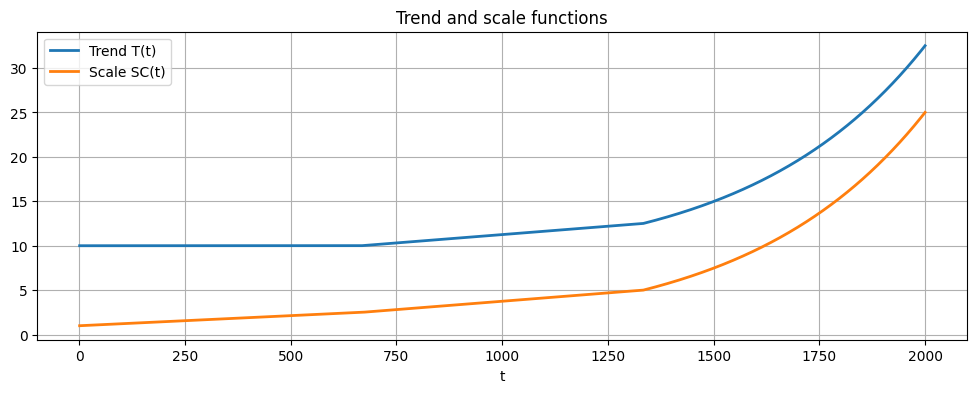

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["T"], label="Trend T(t)", linewidth=2)
plt.plot(t, simulation["SC"], label="Scale SC(t)", linewidth=2)
plt.title("Trend and scale functions")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
est = estimate_1d_model(
    simulation["S"],
    trend_window=101,
    scale_window=151,
    p_max=5,
    h_max=30,
    include_zero_order=True,
    relative_tolerance=0.10,
)

summarize_1d_estimation(est)

One-dimensional estimation summary
---------------------------------
Estimated AR order p_opt: 1
Estimated phi: [0.50130107]
Estimated intercept: 0.0
Estimated alpha: 1.9127

AR order candidates:
  p=0: K=0.251303
  p=1: K=0.00372695
  p=2: K=0.00390953
  p=3: K=0.00393131
  p=4: K=0.00357815
  p=5: K=0.00373268


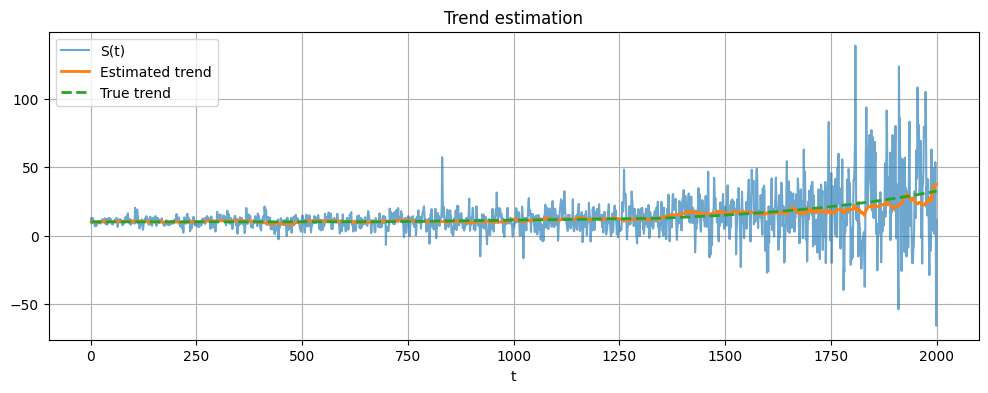

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], label="S(t)", alpha=0.65)
plt.plot(t, est["T_hat"], label="Estimated trend", linewidth=2)
plt.plot(t, simulation["T"], label="True trend", linewidth=2, linestyle="--")
plt.title("Trend estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

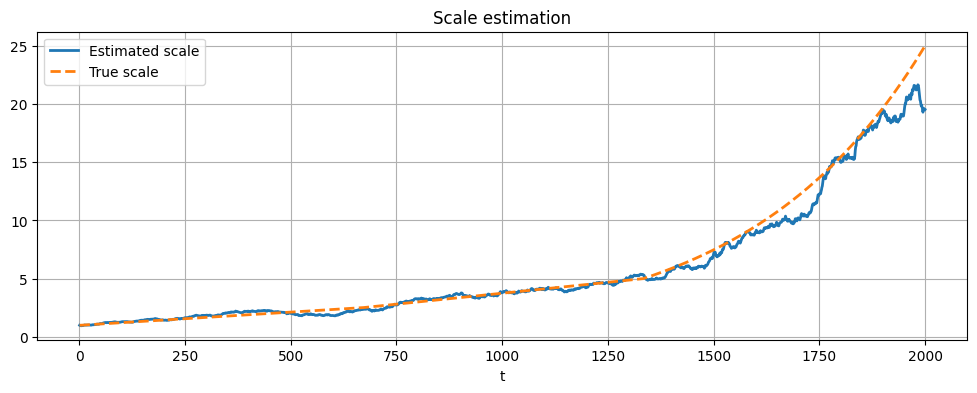

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["SC_hat"], label="Estimated scale", linewidth=2)
plt.plot(t, simulation["SC"], label="True scale", linewidth=2, linestyle="--")
plt.title("Scale estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

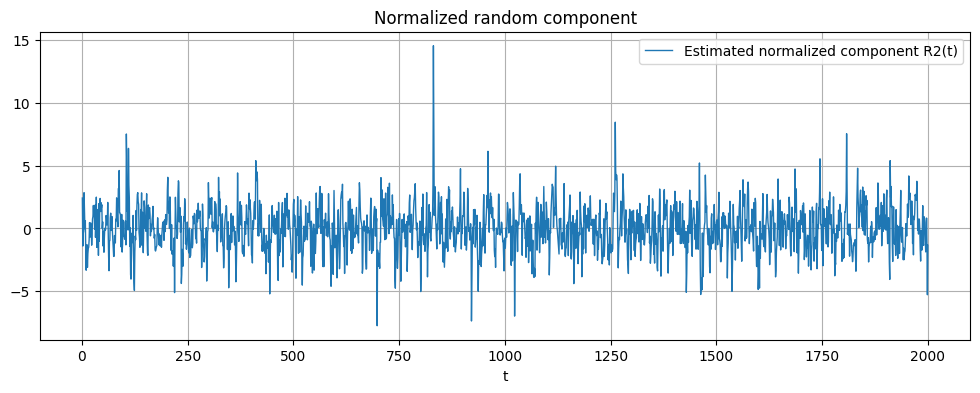

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["R2_hat"], label="Estimated normalized component R2(t)", linewidth=1)
plt.title("Normalized random component")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t_res = np.arange(1, len(est["R3_hat"]) + 1)

plt.figure(figsize=(12, 4))
plt.plot(t_res, est["R3_hat"], linewidth=1, label=r"$\hat{R3}(t)$")
plt.axhline(0, color="red", linewidth=1)
plt.title("Residuals after AR(1) fitting")
plt.xlabel("t")
plt.ylabel(r"$\hat{R3}(t)$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


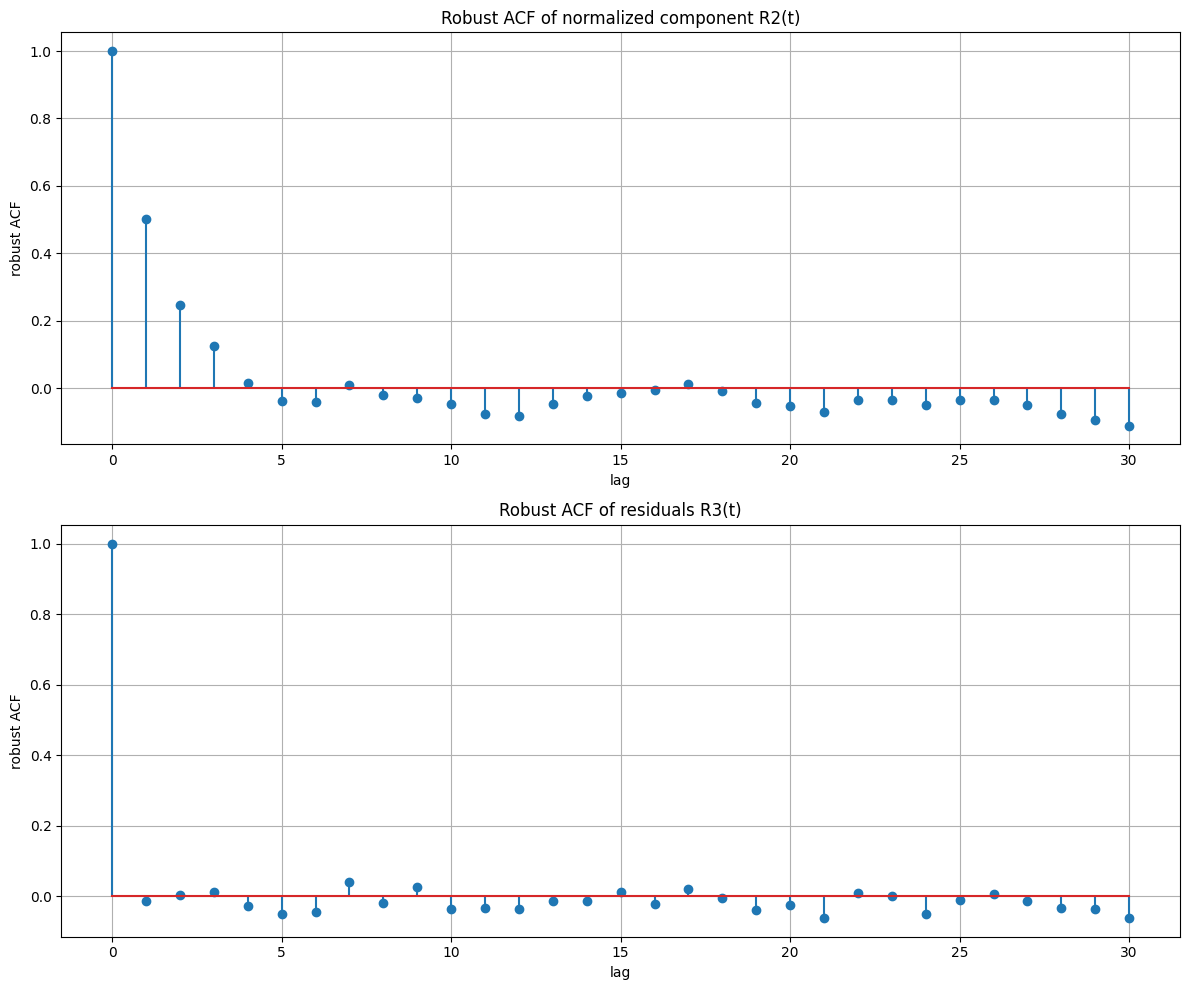

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].stem(range(len(est["acf_R2"])), est["acf_R2"])
axes[0].set_title("Robust ACF of normalized component R2(t)")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("robust ACF")
axes[0].grid(True)

axes[1].stem(range(len(est["acf_R3"])), est["acf_R3"])
axes[1].set_title("Robust ACF of residuals R3(t)")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("robust ACF")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
single_run_summary = pd.DataFrame({
    "parameter": ["alpha", "phi", "AR order"],
    "true value": [1.9, 0.5, 1],
    "estimated value": [
        est["alpha_hat"],
        est["phi_hat"][0] if len(est["phi_hat"]) > 0 else np.nan,
        est["p_opt"],
    ],
})

single_run_summary

,parameter,true value,estimated value
0,alpha,1.9,1.912686
1,phi,0.5,0.501301
2,AR order,1.0,1.000000


## 1D Monte Carlo Figures

The Monte Carlo experiment uses $N=2000$, $M=100$, $\phi_{true}=0.5$ and $\alpha\in\{1.85,1.90,1.95,2.00\}$. The figures below select $\alpha=1.90$ for slide readability.


In [6]:
def run_mc_1d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=10_000,
    trend_window=501,
    scale_window=151,
):
    T_hats = []
    SC_hats = []
    phi_hats = []
    alpha_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_1d_model(
            **base_params,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_1d_model_fixed_ar_order(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            ar_order=1,
            h_max=30,
            compute_diagnostics=(rep == 0),
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        phi_hats.append(est_rep["phi_hat"][0])
        alpha_hats.append(est_rep["alpha_hat"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    return {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "phi_hats": np.asarray(phi_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

In [8]:
def plot_1d_trend_trajectories(result):
    alpha = result["alpha"]
    t = result["t"]
    true_trend = result["true_T"]
    trend_estimates = result["T_hats"]

    plt.figure(figsize=(8, 5))

    for tr in trend_estimates:
        plt.plot(t, tr, color="gray", alpha=0.15, linewidth=0.8)

    plt.plot(t, true_trend, color="blue", linewidth=2.5, label="True trend")

    plt.title(rf"Estimated trend trajectories, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("T(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_1d_scale_trajectories(result):
    alpha = result["alpha"]
    t = result["t"]
    true_scale = result["true_SC"]
    scale_estimates = result["SC_hats"]

    plt.figure(figsize=(8, 5))

    for sc in scale_estimates:
        plt.plot(t, sc, color="gray", alpha=0.15, linewidth=0.8)

    plt.plot(t, true_scale, color="orange", linewidth=2.5, label="True scale")

    plt.title(rf"Estimated scale trajectories, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("SC(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def plot_1d_phi_boxplot(result, true_phi=0.5):
    phi_hats = result["phi_hats"]

    plt.figure(figsize=(5, 5))
    plt.boxplot(phi_hats)
    plt.axhline(true_phi, color="red", linestyle="--", label=rf"true $\phi={true_phi}$")

    plt.title("Distribution of AR(1) coefficient estimates")
    plt.ylabel(r"$\hat{\phi}$")
    plt.xticks([1], [r"$\hat{\phi}$"])
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_1d_alpha_boxplot(result):
    alpha_hats = np.array(result["alpha_hats"])
    true_alpha = result["alpha"]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.boxplot(alpha_hats, tick_labels=[r'$\hat{\alpha}$'], showfliers=True)
    ax.axhline(true_alpha, color="red", linestyle="--", label=fr"true $\alpha$ = {true_alpha}")

    ymin = min(alpha_hats.min() - 0.02, true_alpha - 0.08)
    ymax = max(2.03, alpha_hats.max() + 0.02)   # ważne: trochę miejsca nad 2
    ax.set_ylim(ymin, ymax)

    ax.set_title(fr"Distribution of stability index estimates, $\alpha = {true_alpha}$")
    ax.set_ylabel(r'$\hat{\alpha}$')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [12]:
def plot_1d_acf_before(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    acf_before = est_rep["acf_R2"]
    R2_hat = est_rep["R2_hat"]

    lags = np.arange(len(acf_before))
    band = 1.96 / np.sqrt(len(R2_hat))

    plt.figure(figsize=(8, 4.5))
    plt.stem(lags, acf_before)
    plt.axhline(0, color="red", linewidth=1)
    plt.axhline(band, linestyle="--", label="95% band")
    plt.axhline(-band, linestyle="--")

    plt.title(rf"Before AR(1): robust ACF of $R2(t)$, $\alpha={alpha}$")
    plt.xlabel("Lag")
    plt.ylabel("Robust ACF")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_1d_acf_after(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    acf_after = est_rep["acf_R3"]
    R3_hat = est_rep["R3_hat"]

    lags = np.arange(len(acf_after))
    band = 1.96 / np.sqrt(len(R3_hat))

    plt.figure(figsize=(8, 4.5))
    plt.stem(lags, acf_after)
    plt.axhline(0, color="red", linewidth=1)
    plt.axhline(band, linestyle="--", label="95% band")
    plt.axhline(-band, linestyle="--")

    plt.title(rf"After AR(1): robust ACF of residuals, $\alpha={alpha}$")
    plt.xlabel("Lag")
    plt.ylabel("Robust ACF")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_1d_median_trend(result):
    alpha = result["alpha"]
    t = result["t"]

    true_trend = result["true_T"]
    T_hats = result["T_hats"]

    median_trend = np.median(T_hats, axis=0)
    q05_trend = np.quantile(T_hats, 0.05, axis=0)
    q95_trend = np.quantile(T_hats, 0.95, axis=0)

    plt.figure(figsize=(8, 5))
    plt.fill_between(t, q05_trend, q95_trend, alpha=0.25, label="5%-95% band")
    plt.plot(t, true_trend, linestyle="--", linewidth=2.2, label="True trend")
    plt.plot(t, median_trend, linewidth=2.2, label="Median estimated trend")

    plt.title(rf"Median trend estimate, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("T(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_1d_median_scale(result):
    alpha = result["alpha"]
    t = result["t"]

    true_scale = result["true_SC"]
    SC_hats = result["SC_hats"]

    median_scale = np.median(SC_hats, axis=0)
    q05_scale = np.quantile(SC_hats, 0.05, axis=0)
    q95_scale = np.quantile(SC_hats, 0.95, axis=0)

    plt.figure(figsize=(8, 5))
    plt.fill_between(t, q05_scale, q95_scale, alpha=0.25, label="5%-95% band")
    plt.plot(t, true_scale, linestyle="--", linewidth=2.2, label="True scale")
    plt.plot(t, median_scale, linewidth=2.2, label="Median estimated scale")

    plt.title(rf"Median scale estimate, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("SC(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_1d_residuals_after_ar(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    R3_hat = est_rep["R3_hat"]
    t_res = np.arange(1, len(R3_hat) + 1)

    plt.figure(figsize=(9, 4.5))
    plt.plot(t_res, R3_hat, linewidth=1)

    plt.axhline(0, color="red", linewidth=1)

    plt.title(rf"Estimated residuals after AR(1), $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel(r"$\hat{R3}(t)$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_1d_normalized_component(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    R2_hat = est_rep["R2_hat"]
    t = np.arange(1, len(R2_hat) + 1)

    plt.figure(figsize=(9, 4.5))
    plt.plot(t, R2_hat, linewidth=1)

    plt.axhline(0, color="red", linewidth=1)

    plt.title(rf"Estimated normalized random component $R2(t)$, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel(r"$\hat{R2}(t)$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
mc_1d_final = {}

alphas_order = [1.85, 1.90, 1.95, 2.00]
n_replications = 100

for idx, alpha in enumerate(alphas_order):
    print(f"Running FINAL Monte Carlo for alpha={alpha}...")
    mc_1d_final[alpha] = run_mc_1d_for_alpha(
        alpha=alpha,
        n_replications=n_replications,
        base_seed=10_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
    )

print("Done.")

Running FINAL Monte Carlo for alpha=1.85...
Running FINAL Monte Carlo for alpha=1.9...
Running FINAL Monte Carlo for alpha=1.95...
Running FINAL Monte Carlo for alpha=2.0...
Done.


In [19]:
mc_summary_rows = []

for alpha in alphas_order:
    result = mc_1d_final[alpha]

    mc_summary_rows.append({
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "mean_phi_hat": np.mean(result["phi_hats"]),
        "std_phi_hat": np.std(result["phi_hats"], ddof=1),
        "median_phi_hat": np.median(result["phi_hats"]),
        "true_phi": 0.5,
        "n_replications": n_replications,
    })

mc_summary_1d = pd.DataFrame(mc_summary_rows)
mc_summary_1d

,true_alpha,mean_alpha_hat,std_alpha_hat,median_alpha_hat,mean_phi_hat,std_phi_hat,median_phi_hat,true_phi,n_replications
0,1.85,1.867957,0.072825,1.866071,0.506525,0.020441,0.507124,0.5,100
1,1.90,1.908314,0.064777,1.913825,0.500638,0.021544,0.502745,0.5,100
2,1.95,1.939421,0.057825,1.954353,0.496793,0.020993,0.495754,0.5,100
3,2.00,1.971059,0.046542,2.000000,0.491720,0.022605,0.494268,0.5,100


Selected 1D slide figures for $\alpha=1.90$: trend, scale, normalized component, residuals, ACF before/after AR(1), and boxplots of $\phi$ and $\alpha$.


In [ ]:
res_1d = mc_1d_final[1.90]

plot_1d_trend_trajectories(res_1d)
plot_1d_scale_trajectories(res_1d)
plot_1d_normalized_component(res_1d)
plot_1d_residuals_after_ar(res_1d)
plot_1d_acf_before(res_1d)
plot_1d_acf_after(res_1d)
plot_1d_phi_boxplot(res_1d)
plot_1d_alpha_boxplot(res_1d)


## 2D Model: Simulation and Estimation

The 2D model shares the same regime-change points across components, but each component has its own trend and scale. The normalized vector component is fitted with VAR(1), and the innovations are sub-Gaussian $S\alpha S$.


In [22]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

Theta_true = np.array([
    [0.5, 0.2],
    [-0.1, 0.6],
])

Sigma_true = np.array([
    [0.64, 0.32],
    [0.32, 0.64],
])

base_params_2d = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    Theta=Theta_true,
    Sigma=Sigma_true,
    sigma_1=np.array([1.0, 0.8]),
    sigma_2=np.array([2.5, 1.5]),
    sigma_3=np.array([5.0, 2.0]),
    sigma_4=np.array([25.0, 10.0]),
    c1=np.array([10.0, -5.0]),
)

In [ ]:
sim2d = simulate_2d_model(
    **base_params_2d,
    alpha=1.9,
    random_state=42,
)


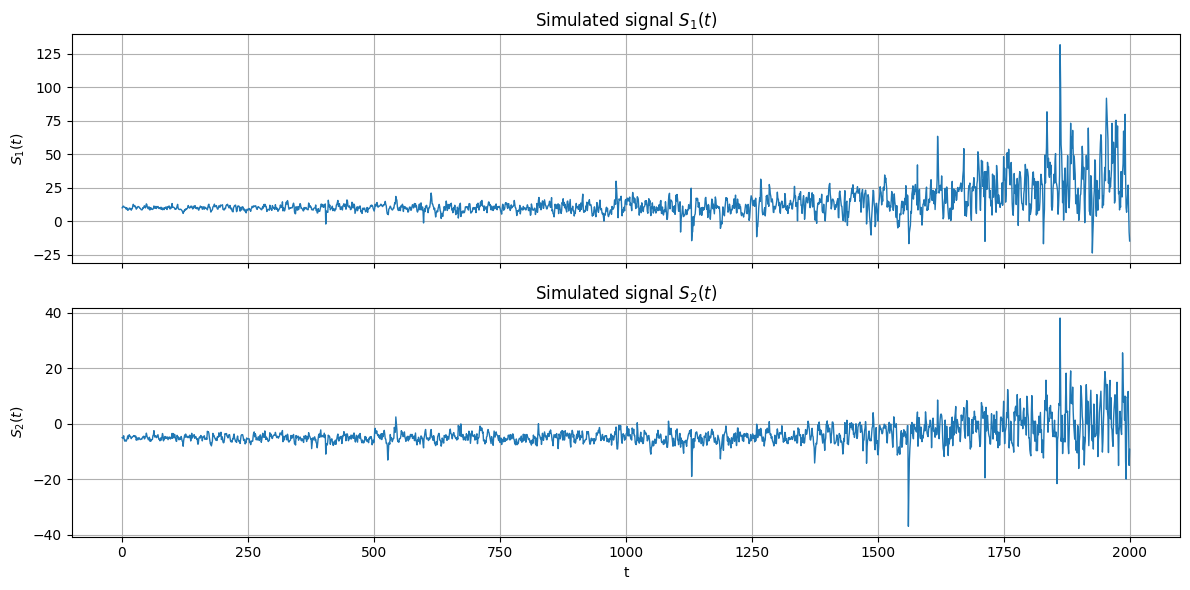

In [24]:
t = sim2d["t"]
S = sim2d["S"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, S[:, 0], linewidth=1)
axes[0].set_title(r"Simulated signal $S_1(t)$")
axes[0].set_ylabel(r"$S_1(t)$")
axes[0].grid(True)

axes[1].plot(t, S[:, 1], linewidth=1)
axes[1].set_title(r"Simulated signal $S_2(t)$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$S_2(t)$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [25]:
def _get_time_axis_from_array(arr):
    n = np.asarray(arr).shape[0]
    return np.arange(n)

def _to_array(x):
    return np.asarray(x)

def _get_rep_sim(result):
    return result["representative_sim"]

def _get_rep_est(result):
    return result["representative_est"]

In [26]:
def plot_true_2d_trends(sim_2d):
    T = _to_array(sim_2d["T"])
    t = sim_2d.get("t", _get_time_axis_from_array(T))

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    axes[0].plot(t, T[:, 0], linewidth=2)
    axes[0].set_title(r"Trend $T_1(t)$")
    axes[0].set_ylabel(r"$T_1(t)$")
    axes[0].grid(True)

    axes[1].plot(t, T[:, 1], linewidth=2)
    axes[1].set_title(r"Trend $T_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$T_2(t)$")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

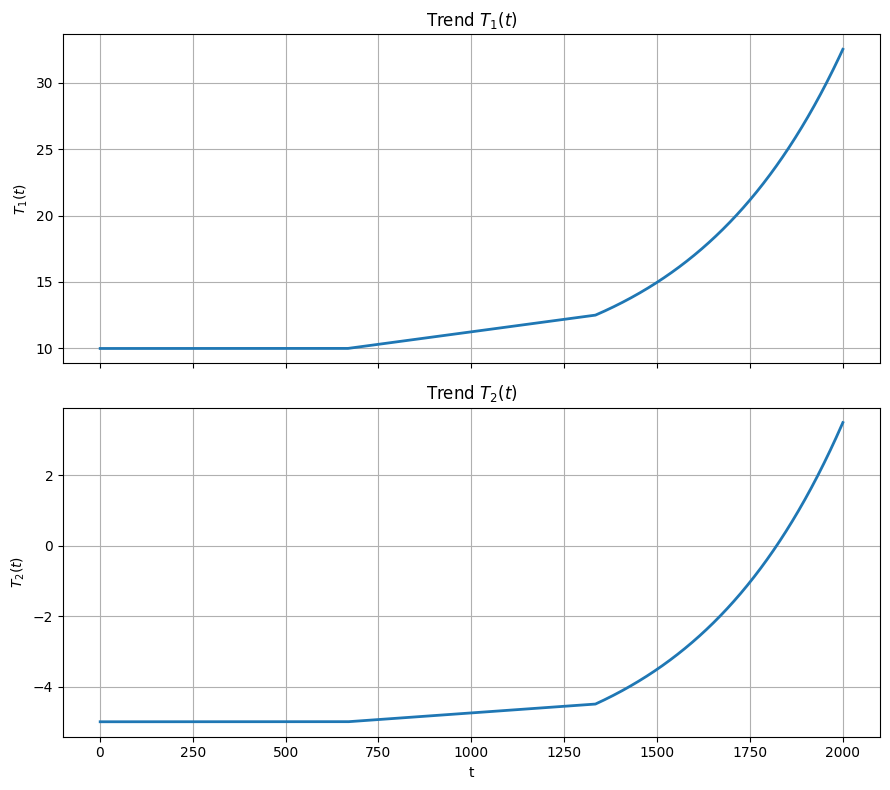

In [30]:
plot_true_2d_trends(sim2d)

In [27]:
def plot_true_2d_scales(sim_2d):
    SC = _to_array(sim_2d["SC"])
    t = sim_2d.get("t", _get_time_axis_from_array(SC))

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    axes[0].plot(t, SC[:, 0], linewidth=2)
    axes[0].set_title(r"Scale $SC_1(t)$")
    axes[0].set_ylabel(r"$SC_1(t)$")
    axes[0].grid(True)

    axes[1].plot(t, SC[:, 1], linewidth=2)
    axes[1].set_title(r"Scale $SC_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$SC_2(t)$")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

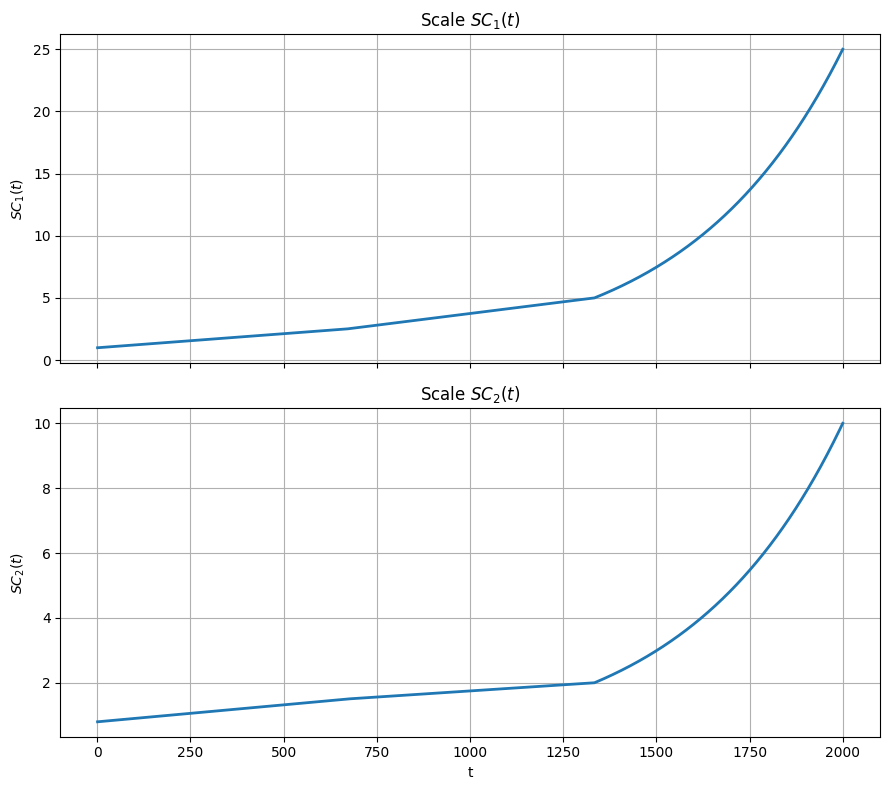

In [31]:
plot_true_2d_scales(sim2d)

In [35]:
est2d = estimate_2d_model_fixed_var1(
    sim2d["S"],
    trend_window=501,
    scale_window=151,
    h_max=30,
    compute_diagnostics=True,
    scale_multiplier=1.6629888237094692,
)

summarize_2d_estimation(est2d)


Two-dimensional estimation summary
----------------------------------
Estimated Theta:
[[ 0.49545282  0.19921618]
 [-0.12965311  0.62248887]]

Estimated alpha: 1.8591

Componentwise alpha:
  alpha_1: 1.8422
  alpha_2: 1.8760


In [71]:
def plot_2d_normalized_component(sim2d, est2d):
    """
    Plots the estimated normalized random component R2_hat(t)
    for both components of the two-dimensional model.
    """
    t = sim2d["t"]
    R2_hat = est2d["R2_hat"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, R2_hat[:, 0], linewidth=1)
    axes[0].axhline(0, color="red", linewidth=1)
    axes[0].set_title(r"Estimated normalized random component $\hat{R2}_1(t)$")
    axes[0].set_ylabel(r"$\hat{R2}_1(t)$")
    axes[0].grid(True)

    axes[1].plot(t, R2_hat[:, 1], linewidth=1)
    axes[1].axhline(0, color="red", linewidth=1)
    axes[1].set_title(r"Estimated normalized random component $\hat{R2}_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$\hat{R2}_2(t)$")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_2d_residuals_after_var(sim2d, est2d):
    """
    Plots the estimated residuals R3_hat(t) after fitting VAR(1)
    for both components of the two-dimensional model.
    """
    R3_hat = est2d["R3_hat"]

    # R3_hat can be shorter than the original signal if lags are removed.
    t_res = np.arange(1, len(R3_hat) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t_res, R3_hat[:, 0], linewidth=1)
    axes[0].axhline(0, color="red", linewidth=1)
    axes[0].set_title(r"Estimated residuals after VAR(1): $\hat{R3}_1(t)$")
    axes[0].set_ylabel(r"$\hat{R3}_1(t)$")
    axes[0].grid(True)

    axes[1].plot(t_res, R3_hat[:, 1], linewidth=1)
    axes[1].axhline(0, color="red", linewidth=1)
    axes[1].set_title(r"Estimated residuals after VAR(1): $\hat{R3}_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$\hat{R3}_2(t)$")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [39]:
def plot_2d_single_trend_estimation(sim2d, est2d):
    t = sim2d["t"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, sim2d["S"][:, 0], alpha=0.35, label=r"$S_1(t)$")
    axes[0].plot(t, sim2d["T"][:, 0], linestyle="--", linewidth=2, label="True trend")
    axes[0].plot(t, est2d["T_hat"][:, 0], linewidth=2, label="Estimated trend")
    axes[0].set_title(r"Trend estimation for $S_1(t)$")
    axes[0].set_ylabel("value")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, sim2d["S"][:, 1], alpha=0.35, label=r"$S_2(t)$")
    axes[1].plot(t, sim2d["T"][:, 1], linestyle="--", linewidth=2, label="True trend")
    axes[1].plot(t, est2d["T_hat"][:, 1], linewidth=2, label="Estimated trend")
    axes[1].set_title(r"Trend estimation for $S_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("value")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_2d_single_scale_estimation(sim2d, est2d):
    t = sim2d["t"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, sim2d["SC"][:, 0], linestyle="--", linewidth=2, label="True scale")
    axes[0].plot(t, est2d["SC_hat"][:, 0], linewidth=2, label="Estimated scale")
    axes[0].set_title(r"Scale estimation for $S_1(t)$")
    axes[0].set_ylabel(r"$SC_1(t)$")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, sim2d["SC"][:, 1], linestyle="--", linewidth=2, label="True scale")
    axes[1].plot(t, est2d["SC_hat"][:, 1], linewidth=2, label="Estimated scale")
    axes[1].set_title(r"Scale estimation for $S_2(t)$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$SC_2(t)$")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

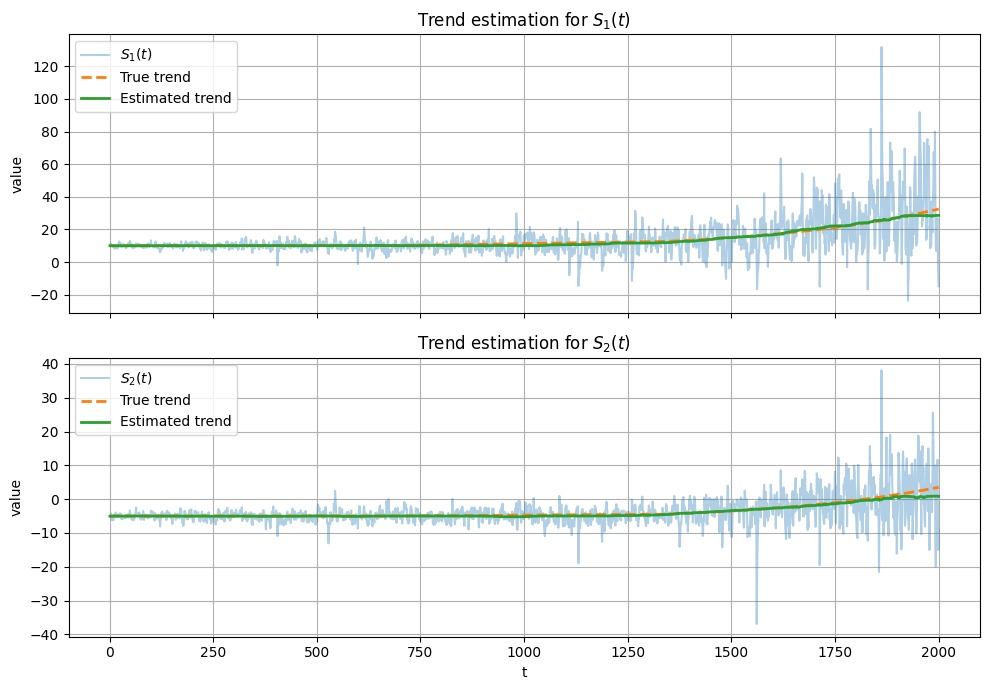

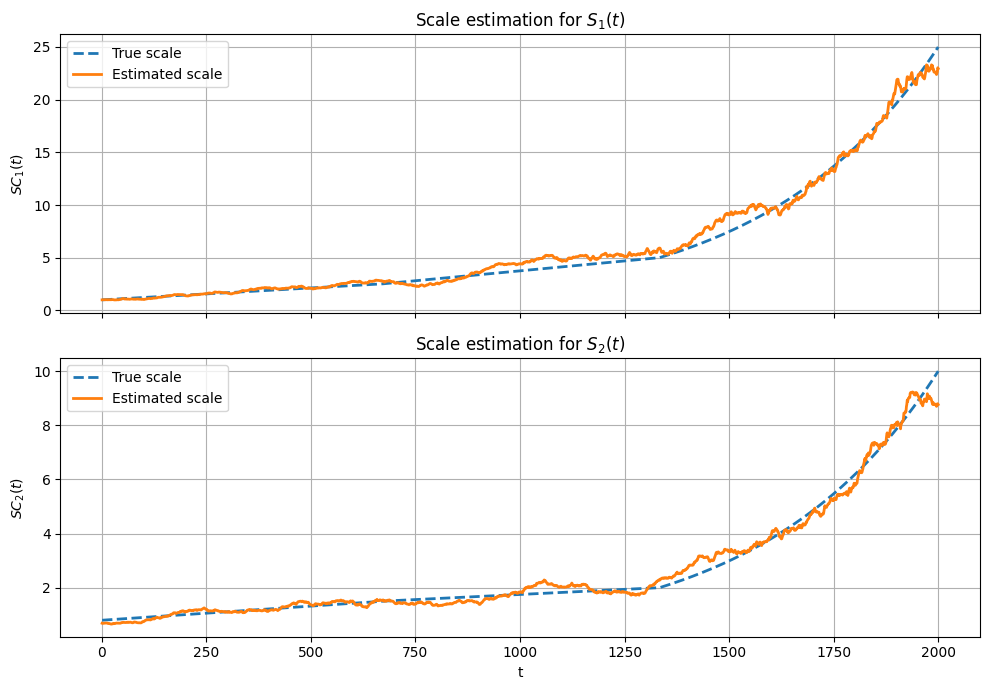

In [40]:
plot_2d_single_trend_estimation(sim2d, est2d)
plot_2d_single_scale_estimation(sim2d, est2d)

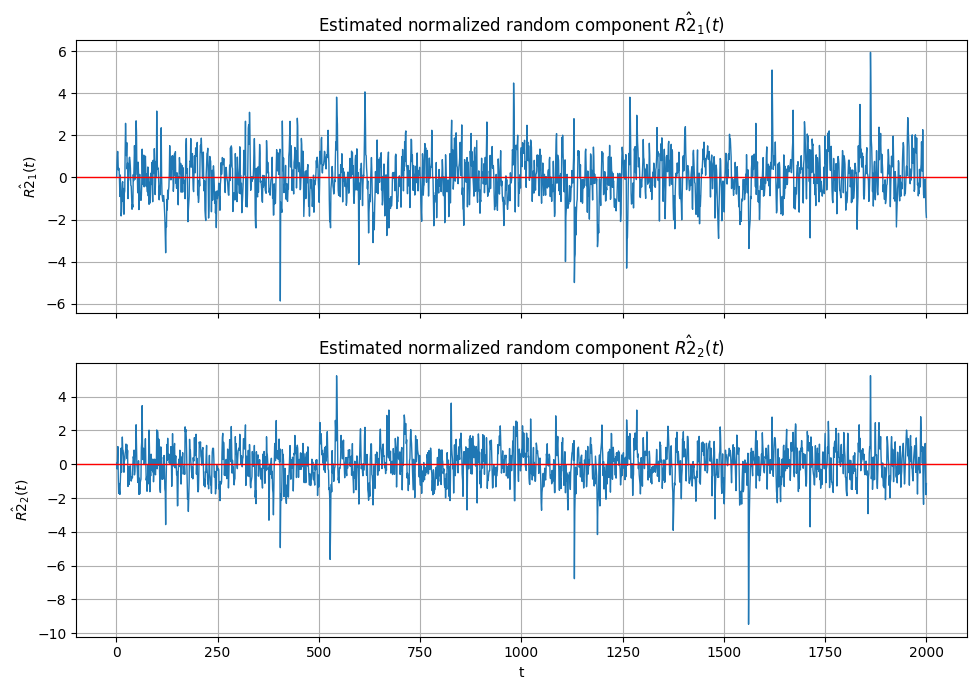

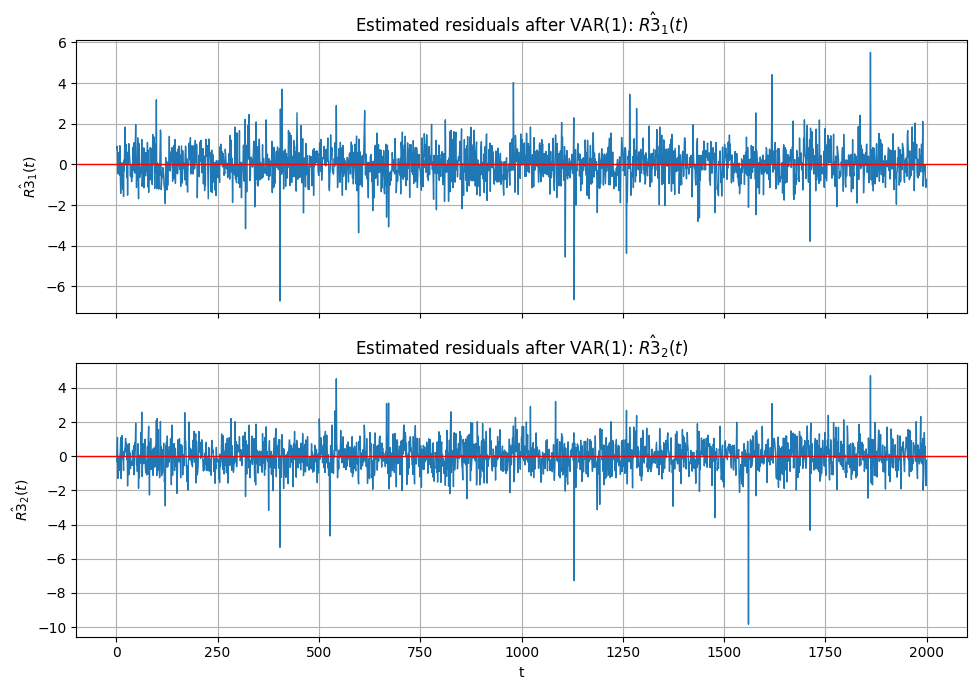

In [73]:
plot_2d_normalized_component(sim2d, est2d)
plot_2d_residuals_after_var(sim2d, est2d)

In [42]:
def plot_2d_acf_ccf_diagnostics(diagnostics, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    acf_1 = diagnostics["acf_1"]
    acf_2 = diagnostics["acf_2"]
    ccf_12 = diagnostics["ccf_12"]
    ccf_21 = diagnostics["ccf_21"]

    axes[0, 0].stem(range(len(acf_1)), acf_1)
    axes[0, 0].set_title(f"{title_prefix} robust ACF of component 1")
    axes[0, 0].set_xlabel("Lag")
    axes[0, 0].set_ylabel("ACF")
    axes[0, 0].grid(True)

    axes[0, 1].stem(range(len(ccf_12)), ccf_12)
    axes[0, 1].set_title(f"{title_prefix} robust CCF: component 1 vs 2")
    axes[0, 1].set_xlabel("Lag")
    axes[0, 1].set_ylabel("CCF")
    axes[0, 1].grid(True)

    axes[1, 0].stem(range(len(ccf_21)), ccf_21)
    axes[1, 0].set_title(f"{title_prefix} robust CCF: component 2 vs 1")
    axes[1, 0].set_xlabel("Lag")
    axes[1, 0].set_ylabel("CCF")
    axes[1, 0].grid(True)

    axes[1, 1].stem(range(len(acf_2)), acf_2)
    axes[1, 1].set_title(f"{title_prefix} robust ACF of component 2")
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("ACF")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

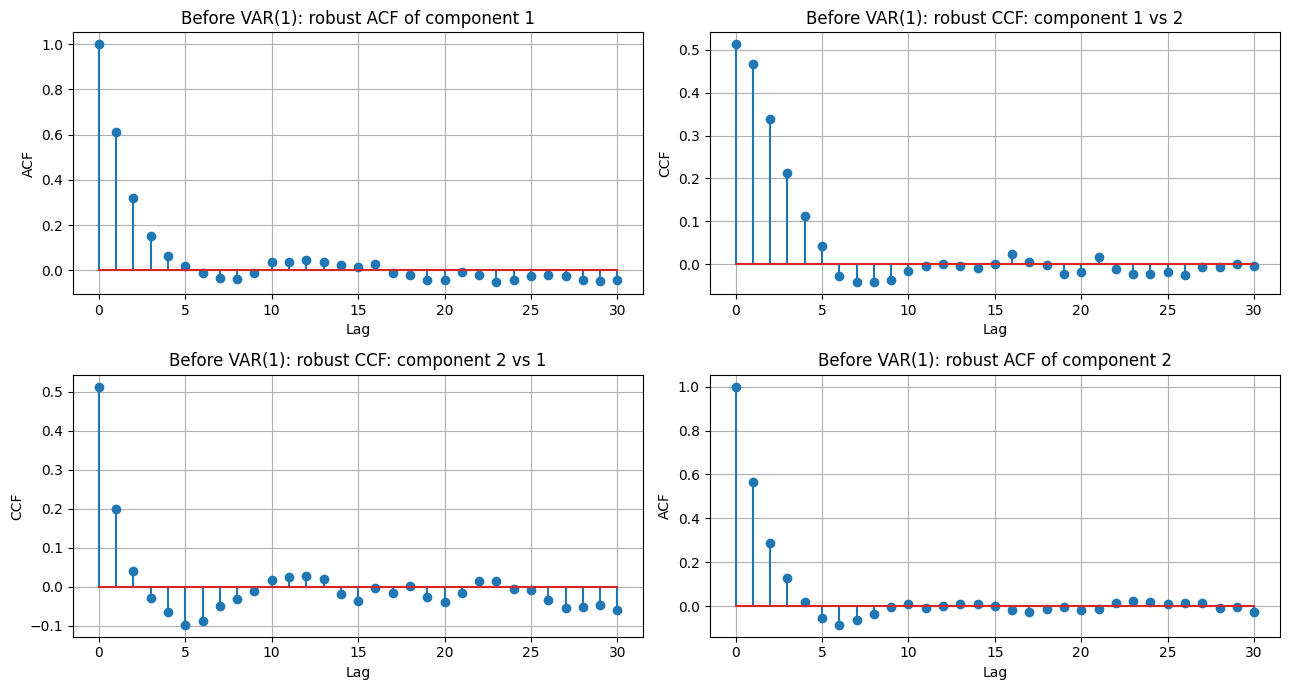

In [43]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R2"],
    title_prefix="Before VAR(1):"
)

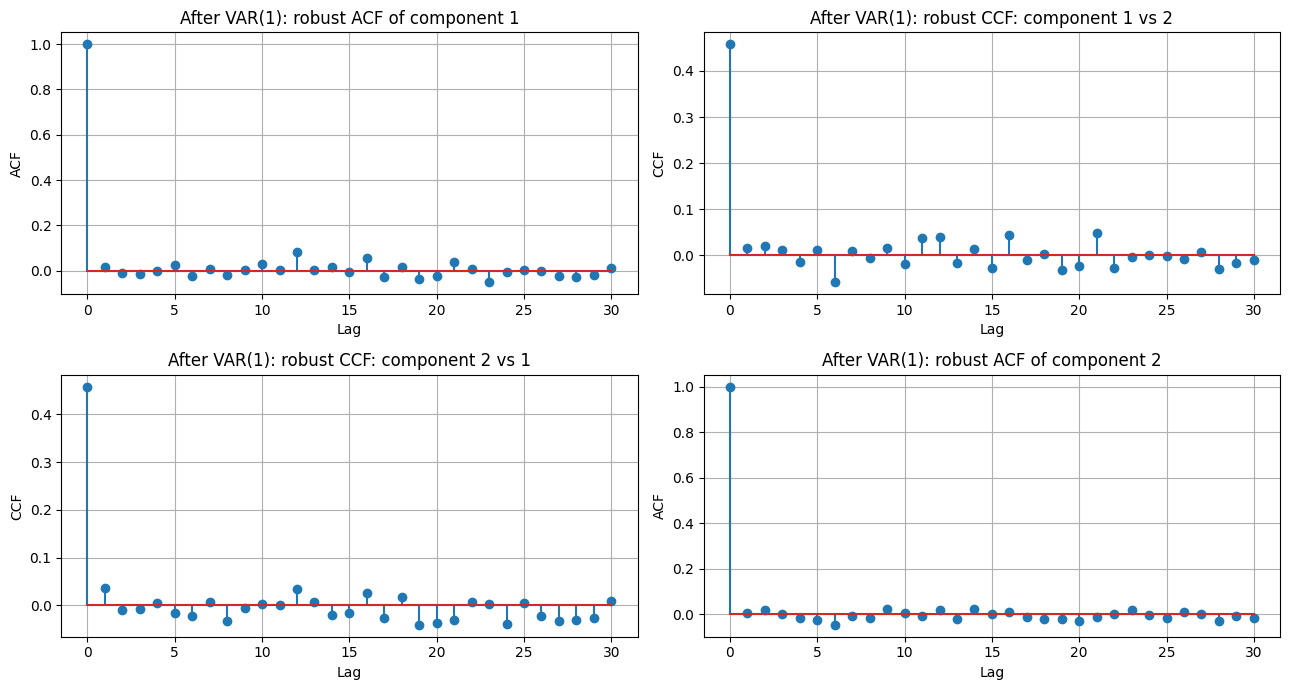

In [44]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R3"],
    title_prefix="After VAR(1):"
)

## 2D Monte Carlo Figures

The 2D Monte Carlo experiment uses $N=2000$, $M=100$, the true $\Theta$ and $\Sigma$ matrices from the report, and the same four stability indices. For slides we again show the most readable set for $\alpha=1.90$.


In [46]:
scale_multiplier_2d = 1.6629888237094692
scale_multiplier_2d

1.6629888237094692

In [48]:
def run_mc_2d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=20_000,
    trend_window=501,
    scale_window=151,
    scale_multiplier=1.0,
):
    T_hats = []
    SC_hats = []
    Theta_hats = []
    alpha_hats = []
    alpha_1_hats = []
    alpha_2_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_2d_model(
            **base_params_2d,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_2d_model_fixed_var1(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            h_max=30,
            compute_diagnostics=(rep == 0),
            scale_multiplier=scale_multiplier,
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        Theta_hats.append(est_rep["Theta_hat"])
        alpha_hats.append(est_rep["alpha_hat"])
        alpha_1_hats.append(est_rep["alpha_info"]["alpha_1"])
        alpha_2_hats.append(est_rep["alpha_info"]["alpha_2"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    return {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "true_Theta": representative_sim["Theta"],
        "true_Sigma": representative_sim["Sigma"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "Theta_hats": np.asarray(Theta_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "alpha_1_hats": np.asarray(alpha_1_hats),
        "alpha_2_hats": np.asarray(alpha_2_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

In [76]:
def plot_mc_2d_trends(result):
    alpha = result["alpha"]
    t = result["t"]

    T_hats = result["T_hats"]
    true_T = result["true_T"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for T_hat in T_hats:
        axes[0].plot(t, T_hat[:, 0], color="gray", alpha=0.15, linewidth=0.8)
    axes[0].plot(t, true_T[:, 0], linewidth=2.5, label=r"True $T_1(t)$")
    axes[0].set_title(rf"Estimated trend trajectories $T_1(t)$, $\alpha={alpha}$")
    axes[0].set_ylabel(r"$T_1(t)$")
    axes[0].grid(True)
    axes[0].legend()

    for T_hat in T_hats:
        axes[1].plot(t, T_hat[:, 1], color="gray", alpha=0.15, linewidth=0.8)
    axes[1].plot(t, true_T[:, 1], linewidth=2.5, label=r"True $T_2(t)$")
    axes[1].set_title(rf"Estimated trend trajectories $T_2(t)$, $\alpha={alpha}$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$T_2(t)$")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_mc_2d_scales(result):
    alpha = result["alpha"]
    t = result["t"]

    SC_hats = result["SC_hats"]
    true_SC = result["true_SC"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for SC_hat in SC_hats:
        axes[0].plot(t, SC_hat[:, 0], color="gray", alpha=0.15, linewidth=0.8)
    axes[0].plot(t, true_SC[:, 0], linewidth=2.5, label=r"True $SC_1(t)$")
    axes[0].set_title(rf"Estimated scale trajectories $SC_1(t)$, $\alpha={alpha}$")
    axes[0].set_ylabel(r"$SC_1(t)$")
    axes[0].grid(True)
    axes[0].legend()

    for SC_hat in SC_hats:
        axes[1].plot(t, SC_hat[:, 1], color="gray", alpha=0.15, linewidth=0.8)
    axes[1].plot(t, true_SC[:, 1], linewidth=2.5, label=r"True $SC_2(t)$")
    axes[1].set_title(rf"Estimated scale trajectories $SC_2(t)$, $\alpha={alpha}$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$SC_2(t)$")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_theta_boxplots_2d(result):
    """
    Boxplots of all entries of the estimated VAR(1) matrix Theta
    in one 2x2 figure.
    """
    alpha = result["alpha"]
    Theta_hats = np.asarray(result["Theta_hats"])
    true_Theta = np.asarray(result["true_Theta"])

    entries = [
        (0, 0, r"$\hat{\Theta}_{11}$", true_Theta[0, 0]),
        (0, 1, r"$\hat{\Theta}_{12}$", true_Theta[0, 1]),
        (1, 0, r"$\hat{\Theta}_{21}$", true_Theta[1, 0]),
        (1, 1, r"$\hat{\Theta}_{22}$", true_Theta[1, 1]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    for ax, (i, j, label, true_value) in zip(axes.ravel(), entries):
        values = Theta_hats[:, i, j]

        ax.boxplot(values, tick_labels=[label], showfliers=True)
        ax.axhline(
            true_value,
            color="red",
            linestyle="--",
            label=rf"true = {true_value:.2f}"
        )

        ax.set_title(f"Distribution of {label}")
        ax.set_ylabel(label)
        ax.grid(True, axis="y")
        ax.legend()

    fig.suptitle(
        rf"Distribution of VAR(1) matrix estimates, $\alpha={alpha}$",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

def plot_alpha_2d_boxplot(result):
    alpha = result["alpha"]

    plt.figure(figsize=(5, 5))
    plt.boxplot(result["alpha_hats"], tick_labels=[r"$\hat{\alpha}$"])
    plt.axhline(alpha, linestyle="--", color="red", label=rf"true $\alpha={alpha}$")
    plt.title(rf"Distribution of stability index estimates, $\alpha={alpha}$")
    plt.ylabel(r"$\hat{\alpha}$")
    plt.grid(True, axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [50]:
def plot_2d_acf_ccf_with_band(diagnostics, n_obs, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    names = [
        ("acf_1", "ACF component 1", axes[0, 0]),
        ("ccf_12", "CCF component 1 vs 2", axes[0, 1]),
        ("ccf_21", "CCF component 2 vs 1", axes[1, 0]),
        ("acf_2", "ACF component 2", axes[1, 1]),
    ]

    band = 1.96 / np.sqrt(n_obs)

    for key, title, ax in names:
        values = diagnostics[key]
        lags = np.arange(len(values))

        ax.stem(lags, values)
        ax.axhline(0, linewidth=1)
        ax.axhline(band, linestyle="--", label="approx. 95% band")
        ax.axhline(-band, linestyle="--")
        ax.set_title(f"{title_prefix} {title}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("value")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_mc_2d_part2(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    diagnostics_R2 = est_rep["diagnostics_R2"]
    diagnostics_R3 = est_rep["diagnostics_R3"]

    R2_hat = est_rep["R2_hat"]
    R3_hat = est_rep["R3_hat"]

    plot_2d_acf_ccf_with_band(
        diagnostics_R2,
        n_obs=len(R2_hat),
        title_prefix=rf"Before VAR(1), $\alpha={alpha}$:"
    )

    plot_2d_acf_ccf_with_band(
        diagnostics_R3,
        n_obs=len(R3_hat),
        title_prefix=rf"After VAR(1), $\alpha={alpha}$:"
    )

    plt.figure(figsize=(6, 5))

    plt.boxplot(result["alpha_hats"], tick_labels=[r"$\hat{\alpha}$"])
    plt.axhline(alpha, linestyle="--", color="red", label=rf"true $\alpha={alpha}$")
    plt.title(rf"Distribution of stability index estimates, $\alpha={alpha}$")
    plt.ylabel(r"$\hat{\alpha}$")
    plt.grid(True)
    plt.legend()
    plt.show()


In [88]:
alphas_order_2d = [1.85, 1.90, 1.95, 2.00]
n_replications_2d = 100

mc_2d_final_scaled = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running scaled 2D Monte Carlo for alpha={alpha}...")
    mc_2d_final_scaled[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        n_replications=n_replications_2d,
        base_seed=20_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
    )

print("Done.")

Running scaled 2D Monte Carlo for alpha=1.85...
Running scaled 2D Monte Carlo for alpha=1.9...
Running scaled 2D Monte Carlo for alpha=1.95...
Running scaled 2D Monte Carlo for alpha=2.0...
Done.


In [53]:
mc_2d_summary_scaled_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_scaled[alpha]
    Theta_hats = result["Theta_hats"]

    mc_2d_summary_scaled_rows.append({
        "true_alpha": alpha,

        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),

        "mean_alpha_1_hat": np.mean(result["alpha_1_hats"]),
        "mean_alpha_2_hat": np.mean(result["alpha_2_hats"]),

        "mean_theta_11": np.mean(Theta_hats[:, 0, 0]),
        "median_theta_11": np.median(Theta_hats[:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],

        "mean_theta_12": np.mean(Theta_hats[:, 0, 1]),
        "median_theta_12": np.median(Theta_hats[:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],

        "mean_theta_21": np.mean(Theta_hats[:, 1, 0]),
        "median_theta_21": np.median(Theta_hats[:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],

        "mean_theta_22": np.mean(Theta_hats[:, 1, 1]),
        "median_theta_22": np.median(Theta_hats[:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],

        "n_replications": n_replications_2d,
    })

mc_2d_summary_scaled = pd.DataFrame(mc_2d_summary_scaled_rows)
mc_2d_summary_scaled

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_alpha_1_hat,mean_alpha_2_hat,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,mean_theta_21,median_theta_21,true_theta_21,mean_theta_22,median_theta_22,true_theta_22,n_replications
0,1.85,1.853972,1.852878,0.046767,1.852139,1.855805,0.488665,0.486248,0.5,0.188118,0.189874,0.2,-0.108152,-0.108307,-0.1,0.596985,0.597428,0.6,100
1,1.90,1.886680,1.890752,0.047744,1.887711,1.885649,0.497038,0.495775,0.5,0.188254,0.189149,0.2,-0.106244,-0.111650,-0.1,0.594643,0.594761,0.6,100
2,1.95,1.941391,1.939242,0.042502,1.941119,1.941662,0.490795,0.492372,0.5,0.195107,0.195034,0.2,-0.116733,-0.116132,-0.1,0.603795,0.608446,0.6,100
3,2.00,1.967227,1.974637,0.032468,1.965264,1.969190,0.490862,0.492024,0.5,0.192216,0.192791,0.2,-0.109185,-0.110934,-0.1,0.596896,0.596507,0.6,100


Selected 2D slide figures for $\alpha=1.90$: trend and scale reconstruction, VAR(1) matrix boxplots, alpha boxplot, and ACF/CCF before and after VAR(1).


In [ ]:
res_2d = mc_2d_final_scaled[1.90]

plot_mc_2d_trends(res_2d)
plot_mc_2d_scales(res_2d)
plot_theta_boxplots_2d(res_2d)
plot_alpha_2d_boxplot(res_2d)
plot_2d_acf_ccf_with_band(
    res_2d["representative_est"]["diagnostics_R2"],
    n_obs=len(res_2d["representative_est"]["R2_hat"]),
    title_prefix=r"Before VAR(1), $\alpha=1.90$:"
)
plot_2d_acf_ccf_with_band(
    res_2d["representative_est"]["diagnostics_R3"],
    n_obs=len(res_2d["representative_est"]["R3_hat"]),
    title_prefix=r"After VAR(1), $\alpha=1.90$:"
)


## Sigma Diagnostics

Raw $\Sigma$ estimates are sensitive to reconstructed scale levels. The adjusted version below is a simulation-only diagnostic because it uses the true scale functions.


In [57]:
est2d_sigma = estimate_2d_model_fixed_var1(
    sim2d["S"],
    trend_window=501,
    scale_window=151,
    h_max=30,
    compute_diagnostics=True,
    scale_multiplier=scale_multiplier_2d,
    estimate_sigma=True,
    sigma_grid_size=9,
    sigma_grid_max=3.0,
    sigma_maxiter=300,
)

summarize_2d_estimation(est2d_sigma)

Two-dimensional estimation summary
----------------------------------
Estimated Theta:
[[ 0.49545282  0.19921618]
 [-0.12965311  0.62248887]]

Estimated alpha: 1.8591

Componentwise alpha:
  alpha_1: 1.8422
  alpha_2: 1.8760

Estimated Sigma:
[[0.55393329 0.2717225 ]
 [0.2717225  0.63126207]]


In [58]:
def run_mc_2d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=20_000,
    trend_window=501,
    scale_window=151,
    scale_multiplier=1.0,
    estimate_sigma=False,
):
    T_hats = []
    SC_hats = []
    Theta_hats = []
    Sigma_hats = []
    alpha_hats = []
    alpha_1_hats = []
    alpha_2_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_2d_model(
            **base_params_2d,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_2d_model_fixed_var1(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            h_max=30,
            compute_diagnostics=(rep == 0),
            scale_multiplier=scale_multiplier,
            estimate_sigma=estimate_sigma,
            sigma_grid_size=9,
            sigma_grid_max=3.0,
            sigma_maxiter=300,
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        Theta_hats.append(est_rep["Theta_hat"])
        alpha_hats.append(est_rep["alpha_hat"])
        alpha_1_hats.append(est_rep["alpha_info"]["alpha_1"])
        alpha_2_hats.append(est_rep["alpha_info"]["alpha_2"])

        if estimate_sigma:
            Sigma_hats.append(est_rep["Sigma_hat"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    result = {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "true_Theta": representative_sim["Theta"],
        "true_Sigma": representative_sim["Sigma"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "Theta_hats": np.asarray(Theta_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "alpha_1_hats": np.asarray(alpha_1_hats),
        "alpha_2_hats": np.asarray(alpha_2_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

    if estimate_sigma:
        result["Sigma_hats"] = np.asarray(Sigma_hats)

    return result

In [59]:
n_replications_2d_sigma = 100

mc_2d_final_sigma = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running 2D Monte Carlo with Sigma estimation for alpha={alpha}...")
    mc_2d_final_sigma[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        n_replications=n_replications_2d_sigma,
        base_seed=40_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
        estimate_sigma=True,
    )

print("Done.")

Running 2D Monte Carlo with Sigma estimation for alpha=1.85...
Running 2D Monte Carlo with Sigma estimation for alpha=1.9...
Running 2D Monte Carlo with Sigma estimation for alpha=1.95...
Running 2D Monte Carlo with Sigma estimation for alpha=2.0...
Done.


In [60]:
mc_2d_sigma_summary_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_sigma[alpha]
    Theta_hats = result["Theta_hats"]
    Sigma_hats = result["Sigma_hats"]

    mc_2d_sigma_summary_rows.append({
        "true_alpha": alpha,

        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),

        "mean_theta_11": np.mean(Theta_hats[:, 0, 0]),
        "median_theta_11": np.median(Theta_hats[:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],

        "mean_theta_12": np.mean(Theta_hats[:, 0, 1]),
        "median_theta_12": np.median(Theta_hats[:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],

        "mean_theta_21": np.mean(Theta_hats[:, 1, 0]),
        "median_theta_21": np.median(Theta_hats[:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],

        "mean_theta_22": np.mean(Theta_hats[:, 1, 1]),
        "median_theta_22": np.median(Theta_hats[:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],

        "mean_sigma_11": np.mean(Sigma_hats[:, 0, 0]),
        "median_sigma_11": np.median(Sigma_hats[:, 0, 0]),
        "true_sigma_11": Sigma_true[0, 0],

        "mean_sigma_12": np.mean(Sigma_hats[:, 0, 1]),
        "median_sigma_12": np.median(Sigma_hats[:, 0, 1]),
        "true_sigma_12": Sigma_true[0, 1],

        "mean_sigma_21": np.mean(Sigma_hats[:, 1, 0]),
        "median_sigma_21": np.median(Sigma_hats[:, 1, 0]),
        "true_sigma_21": Sigma_true[1, 0],

        "mean_sigma_22": np.mean(Sigma_hats[:, 1, 1]),
        "median_sigma_22": np.median(Sigma_hats[:, 1, 1]),
        "true_sigma_22": Sigma_true[1, 1],

        "n_replications": n_replications_2d_sigma,
    })

mc_2d_sigma_summary = pd.DataFrame(mc_2d_sigma_summary_rows)
mc_2d_sigma_summary

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,...,mean_sigma_12,median_sigma_12,true_sigma_12,mean_sigma_21,median_sigma_21,true_sigma_21,mean_sigma_22,median_sigma_22,true_sigma_22,n_replications
0,1.85,1.854486,1.853443,0.055084,0.491884,0.491266,0.5,0.191568,0.191545,0.2,...,0.299845,0.297841,0.32,0.299845,0.297841,0.32,0.641355,0.638989,0.64,100
1,1.90,1.902304,1.912441,0.053956,0.493469,0.493900,0.5,0.189463,0.190143,0.2,...,0.311935,0.312437,0.32,0.311935,0.312437,0.32,0.672648,0.673241,0.64,100
2,1.95,1.935060,1.938023,0.046984,0.492189,0.495645,0.5,0.187710,0.187983,0.2,...,0.329987,0.328058,0.32,0.329987,0.328058,0.32,0.703095,0.705504,0.64,100
3,2.00,1.966646,1.976907,0.033629,0.498085,0.499477,0.5,0.188918,0.189737,0.2,...,0.342330,0.340131,0.32,0.342330,0.340131,0.32,0.728588,0.731216,0.64,100


In [61]:
def plot_sigma_boxplots(result):
    Sigma_hats = result["Sigma_hats"]
    true_Sigma = result["true_Sigma"]
    alpha = result["alpha"]

    entries = [
        (0, 0, r"$\hat{\Sigma}_{11}$", true_Sigma[0, 0]),
        (0, 1, r"$\hat{\Sigma}_{12}$", true_Sigma[0, 1]),
        (1, 0, r"$\hat{\Sigma}_{21}$", true_Sigma[1, 0]),
        (1, 1, r"$\hat{\Sigma}_{22}$", true_Sigma[1, 1]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for ax, (i, j, label, true_value) in zip(axes.ravel(), entries):
        values = Sigma_hats[:, i, j]
        ax.boxplot(values, tick_labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=f"true = {true_value:.2f}")
        ax.set_title(f"Distribution of {label}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(rf"Sigma estimation, $\alpha={alpha}$")
    plt.tight_layout()
    plt.show()

Raw Sigma boxplots are shown first; the adjusted version below is a simulation-only diagnostic using the known true scale.


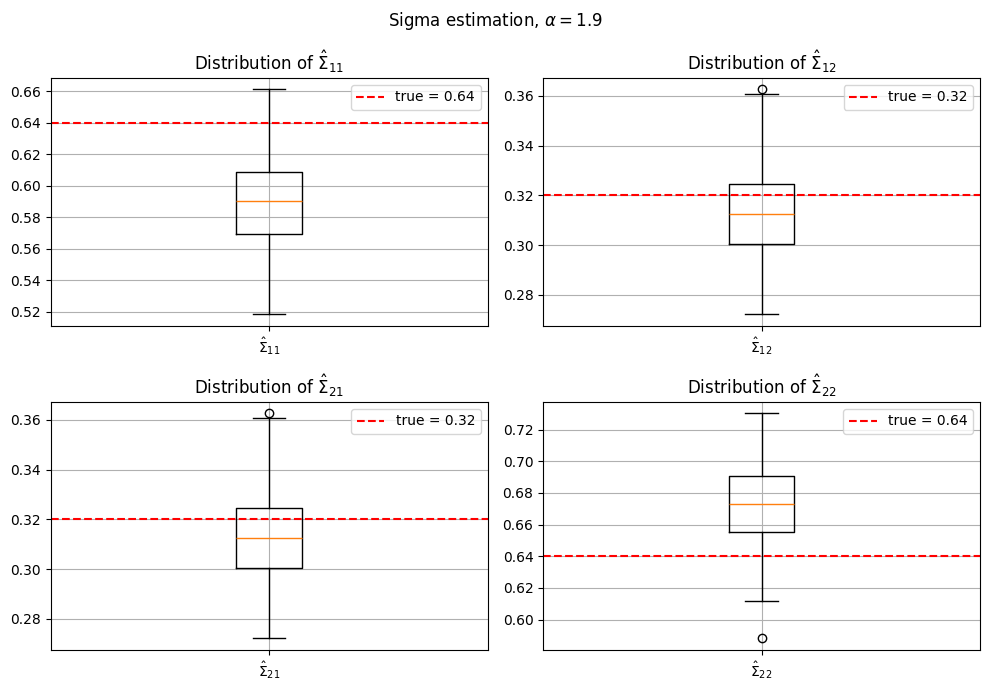

In [62]:
plot_sigma_boxplots(mc_2d_final_sigma[1.9])

In [63]:
def add_scale_adjusted_sigma(mc_2d_results, alphas_order, trim_edges=100):
    """
    Adds scale-adjusted Sigma estimates to Monte Carlo results.

    If the estimated scale is not exactly equal to the true scale, the residuals
    are effectively rescaled. Since Sigma is estimated from these residuals,
    we correct Sigma by the median scale ratio of each component.

    This is a diagnostic correction for simulated data, where the true scale is known.
    """
    for alpha in alphas_order:
        result = mc_2d_results[alpha]

        SC_hats = result["SC_hats"]
        true_SC = result["true_SC"]
        Sigma_hats = result["Sigma_hats"]

        ratios = SC_hats / true_SC[None, :, :]

        if trim_edges > 0:
            ratios_inner = ratios[:, trim_edges:-trim_edges, :]
        else:
            ratios_inner = ratios

        d1 = np.median(ratios_inner[:, :, 0])
        d2 = np.median(ratios_inner[:, :, 1])

        D = np.diag([d1, d2])

        Sigma_hats_adjusted = np.array([
            D @ Sigma_hat @ D
            for Sigma_hat in Sigma_hats
        ])

        result["Sigma_hats_adjusted"] = Sigma_hats_adjusted
        result["sigma_scale_adjustment"] = {
            "d1": d1,
            "d2": d2,
            "D": D,
        }

    return mc_2d_results

In [64]:
mc_2d_final_sigma = add_scale_adjusted_sigma(
    mc_2d_final_sigma,
    alphas_order_2d,
    trim_edges=100,
)

In [67]:
def plot_sigma_boxplots_adjusted(result):
    Sigma_hats = result["Sigma_hats_adjusted"]
    true_Sigma = result["true_Sigma"]
    alpha = result["alpha"]

    entries = [
        (0, 0, r"$\hat{\Sigma}_{11}$", true_Sigma[0, 0]),
        (0, 1, r"$\hat{\Sigma}_{12}$", true_Sigma[0, 1]),
        (1, 0, r"$\hat{\Sigma}_{21}$", true_Sigma[1, 0]),
        (1, 1, r"$\hat{\Sigma}_{22}$", true_Sigma[1, 1]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for ax, (i, j, label, true_value) in zip(axes.ravel(), entries):
        values = Sigma_hats[:, i, j]
        ax.boxplot(values, tick_labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=f"true = {true_value:.2f}")
        ax.set_title(f"Distribution of {label}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(rf"Sigma estimation, $\alpha={alpha}$")
    plt.tight_layout()
    plt.show()

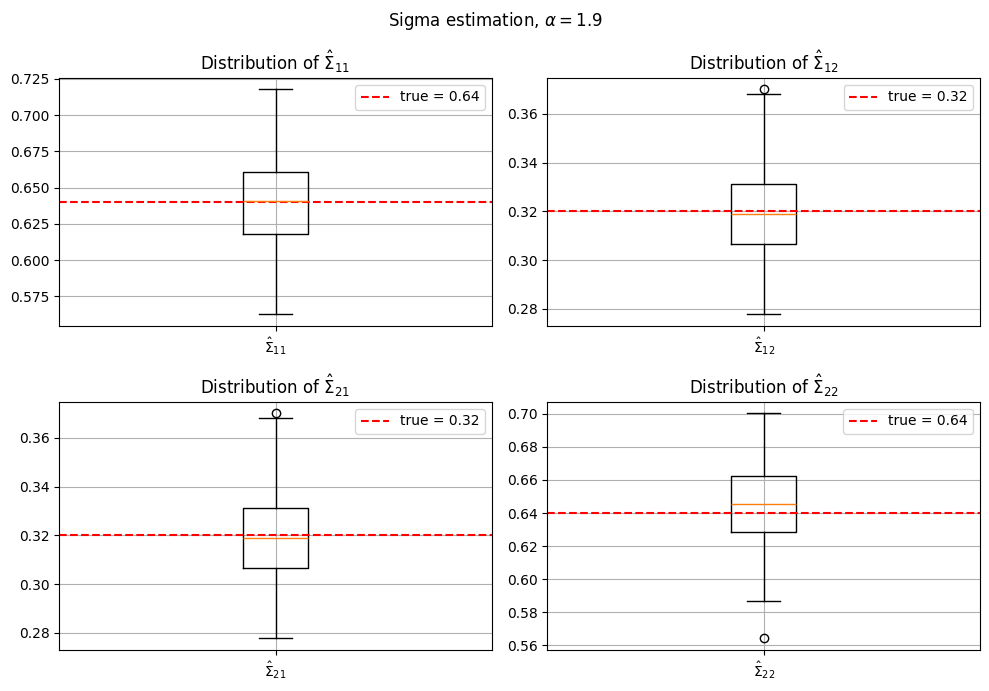

In [68]:
plot_sigma_boxplots_adjusted(mc_2d_final_sigma[1.90])

In [69]:
mc_2d_sigma_adjusted_summary_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_sigma[alpha]
    Sigma_hats_adj = result["Sigma_hats_adjusted"]

    mc_2d_sigma_adjusted_summary_rows.append({
        "true_alpha": alpha,

        "d1_scale_ratio": result["sigma_scale_adjustment"]["d1"],
        "d2_scale_ratio": result["sigma_scale_adjustment"]["d2"],

        "mean_sigma_11_adj": np.mean(Sigma_hats_adj[:, 0, 0]),
        "median_sigma_11_adj": np.median(Sigma_hats_adj[:, 0, 0]),
        "true_sigma_11": Sigma_true[0, 0],

        "mean_sigma_12_adj": np.mean(Sigma_hats_adj[:, 0, 1]),
        "median_sigma_12_adj": np.median(Sigma_hats_adj[:, 0, 1]),
        "true_sigma_12": Sigma_true[0, 1],

        "mean_sigma_21_adj": np.mean(Sigma_hats_adj[:, 1, 0]),
        "median_sigma_21_adj": np.median(Sigma_hats_adj[:, 1, 0]),
        "true_sigma_21": Sigma_true[1, 0],

        "mean_sigma_22_adj": np.mean(Sigma_hats_adj[:, 1, 1]),
        "median_sigma_22_adj": np.median(Sigma_hats_adj[:, 1, 1]),
        "true_sigma_22": Sigma_true[1, 1],
    })

mc_2d_sigma_adjusted_summary = pd.DataFrame(mc_2d_sigma_adjusted_summary_rows)
mc_2d_sigma_adjusted_summary

,true_alpha,d1_scale_ratio,d2_scale_ratio,mean_sigma_11_adj,median_sigma_11_adj,true_sigma_11,mean_sigma_12_adj,median_sigma_12_adj,true_sigma_12,mean_sigma_21_adj,median_sigma_21_adj,true_sigma_21,mean_sigma_22_adj,median_sigma_22_adj,true_sigma_22
0,1.85,1.068317,1.002663,0.640351,0.636694,0.64,0.321182,0.319036,0.32,0.321182,0.319036,0.32,0.644775,0.642397,0.64
1,1.90,1.041907,0.979347,0.639784,0.640598,0.64,0.318295,0.318807,0.32,0.318295,0.318807,0.32,0.645151,0.645720,0.64
2,1.95,1.017835,0.955881,0.641328,0.637132,0.64,0.321054,0.319177,0.32,0.321054,0.319177,0.32,0.642425,0.644625,0.64
3,2.00,0.998018,0.938622,0.644524,0.642719,0.64,0.320682,0.318621,0.32,0.320682,0.318621,0.32,0.641894,0.644209,0.64


The presentation notebook intentionally keeps only selected figures. Detailed interpretation and limitations are documented in the main report notebook.
